In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.interpolate import interp1d
import scipy.io.wavfile
import librosa
import os
import glob

# Add project root to path for importing TinyVAD
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import TinyVAD model
try:
    from models.tinyvad_student import TinyVAD
    print("✓ TinyVAD imported successfully")
except ImportError as e:
    print(f"⚠ Could not import TinyVAD: {e}")
    print("  Make sure you're running from the project root")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")

⚠ Could not import TinyVAD: No module named 'models'
  Make sure you're running from the project root

PyTorch version: 2.11.0
CUDA available: False
MPS available: True


In [2]:
class EnergyVAD:
    """
    Energy-based Voice Activity Detection baseline.
    Uses short-term energy with hysteresis thresholding for speech detection.
    """
    
    def __init__(
        self,
        frame_hop_ms=10,
        threshold=0.5,
        hysteresis_high=0.6,
        hysteresis_low=0.4,
        min_speech_dur=0.25,
        min_silence_dur=0.25,
        smoothing_window=3,
        sr=16000
    ):
        self.frame_hop_ms = frame_hop_ms
        self.threshold = threshold
        self.hysteresis_high = hysteresis_high
        self.hysteresis_low = hysteresis_low
        self.min_speech_dur = min_speech_dur
        self.min_silence_dur = min_silence_dur
        self.smoothing_window = smoothing_window
        self.sr = sr
    
    def get_frame_probs(self, audio):
        """Compute frame-level speech probabilities from audio energy."""
        # Frame parameters: 25ms window, specified hop
        frame_length = int(0.025 * self.sr)
        hop_length = int(self.frame_hop_ms / 1000 * self.sr)
        
        # Compute short-term energy (RMS)
        rms = librosa.feature.rms(
            y=audio,
            frame_length=frame_length,
            hop_length=hop_length
        )[0]
        
        # Normalize energy to [0, 1]
        if rms.max() > 0:
            probs = rms / rms.max()
        else:
            probs = rms.copy()
        
        # Apply median smoothing
        if self.smoothing_window > 1:
            probs = median_filter(probs, size=self.smoothing_window)
        
        # Compute frame timestamps
        times = librosa.frames_to_time(
            np.arange(len(probs)),
            sr=self.sr,
            hop_length=hop_length
        )
        
        return probs, times
    
    def get_segments(self, audio):
        """Detect speech segments using hysteresis thresholding."""
        probs, times = self.get_frame_probs(audio)
        hop_length = int(self.frame_hop_ms / 1000 * self.sr)
        frame_dur = hop_length / self.sr
        
        # Hysteresis thresholding
        is_speech = np.zeros(len(probs), dtype=bool)
        in_speech = False
        
        for i, prob in enumerate(probs):
            if in_speech:
                if prob < self.hysteresis_low:
                    in_speech = False
            else:
                if prob > self.hysteresis_high:
                    in_speech = True
            is_speech[i] = in_speech
        
        # Convert to segments
        segments = []
        start_idx = None
        
        for i, speech in enumerate(is_speech):
            if speech and start_idx is None:
                start_idx = i
            elif not speech and start_idx is not None:
                segments.append((times[start_idx], times[i]))
                start_idx = None
        
        # Handle case where audio ends during speech
        if start_idx is not None:
            segments.append((times[start_idx], times[-1] + frame_dur))
        
        # Merge close segments
        if len(segments) > 1:
            merged = [segments[0]]
            for start, end in segments[1:]:
                prev_start, prev_end = merged[-1]
                if start - prev_end < self.min_silence_dur:
                    merged[-1] = (prev_start, end)
                else:
                    merged.append((start, end))
            segments = merged
        
        # Remove short segments
        segments = [
            (start, end) for start, end in segments
            if end - start >= self.min_speech_dur
        ]
        
        return segments

# Initialize Energy VAD with tuned parameters
energy_vad = EnergyVAD(
    frame_hop_ms=10,
    threshold=0.5,
    hysteresis_high=0.6,
    hysteresis_low=0.4,
    smoothing_window=3
)

print("Energy VAD initialized!")
print(f"Frame hop: {energy_vad.frame_hop_ms}ms")
print(f"Threshold: {energy_vad.threshold}")

Energy VAD initialized!
Frame hop: 10ms
Threshold: 0.5


In [3]:
def load_tinyvad_checkpoint(checkpoint_path='./outputs/quick_test/checkpoints/fold_F01_latest_best.pt', device=None):
    """
    Load the fine-tuned TinyVAD student model from checkpoint.
    
    Args:
        checkpoint_path: Path to the checkpoint file
        device: torch device (auto-detected if None)
    
    Returns:
        model: Loaded TinyVAD model
        checkpoint: Full checkpoint dict with metrics
    """
    if device is None:
        if torch.cuda.is_available():
            device = torch.device('cuda')
        elif torch.backends.mps.is_available():
            device = torch.device('mps')
        else:
            device = torch.device('cpu')
    
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Get model config from checkpoint
    config = checkpoint.get('config', {})
    model_config = config.get('model', {
        'n_mels': 40,
        'cnn_channels': [14, 28],
        'gru_hidden': 32,
        'gru_layers': 2,
        'dropout': 0.1
    })
    
    # Create and load model
    model = TinyVAD(**model_config)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Print model info
    print(f"\n=== TinyVAD Model Info ===")
    print(f"Parameters: {model.count_parameters():,}")
    print(f"Model size: {model.get_model_size_kb():.2f} KB ({model.get_model_size_kb()/1024:.3f} MB)")
    print(f"Checkpoint epoch: {checkpoint.get('epoch', 'N/A')}")
    print(f"Validation AUC: {checkpoint.get('val_auc', 'N/A')}")
    print(f"Device: {device}")
    
    return model, checkpoint, device

# Load the model
tinyvad_model, checkpoint, device = load_tinyvad_checkpoint()

# Try to load the model if checkpoint exists
CHECKPOINT_PATH = "outputs/quick_test/checkpoints/fold_F01_latest_best.pt"
if os.path.exists(CHECKPOINT_PATH):
    try:
        tinyvad_model, checkpoint, device = load_tinyvad_checkpoint(CHECKPOINT_PATH)
    except Exception as e:
        print(f"\n⚠ Error loading model: {e}")
        print("  Model will not be available for comparison")
        tinyvad_model = None
        checkpoint = None
        device = torch.device('cpu')
else:
    print(f"\n⚠ Checkpoint not found: {CHECKPOINT_PATH}")
    print("  Please train the model first or update the path")
    tinyvad_model = None
    checkpoint = None
    device = torch.device('cpu')


Loading checkpoint from: ./outputs/quick_test/checkpoints/fold_F01_latest_best.pt


FileNotFoundError: [Errno 2] No such file or directory: './outputs/quick_test/checkpoints/fold_F01_latest_best.pt'

In [ ]:
def compare_vad_models(audio_path, tinyvad_model, energy_vad, device):
    """
    Run both TinyVAD and Energy VAD on the same audio and compare results.
    
    Args:
        audio_path: Path to audio file
        tinyvad_model: Loaded TinyVAD model
        energy_vad: EnergyVAD instance
        device: torch device
    
    Returns:
        dict with predictions and metrics for both models
    """
    # Load audio
    waveform, sr = torchaudio.load(audio_path)
    if sr != 16000:
        waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
        sr = 16000
    
    audio_np = waveform.squeeze().numpy()
    duration = len(audio_np) / sr
    
    # === TinyVAD Inference ===
    with torch.no_grad():
        tinyvad_probs = tinyvad_model.predict(audio_np, device=device, return_numpy=True)
    
    # TinyVAD outputs ~31 fps (with default config)
    tinyvad_time = np.linspace(0, duration, len(tinyvad_probs))
    
    # === Energy VAD Inference ===
    energy_probs, energy_time = energy_vad.get_frame_probs(audio_np)
    
    # === Align frame rates for comparison ===
    # Interpolate TinyVAD to match Energy VAD frame rate (~100 fps)
    from scipy.interpolate import interp1d
    
    # Create interpolation function for TinyVAD
    tinyvad_interp = interp1d(
        tinyvad_time, 
        tinyvad_probs, 
        kind='linear', 
        bounds_error=False, 
        fill_value='extrapolate'
    )
    
    # Interpolate to Energy VAD time points (within valid range)
    valid_mask = (energy_time >= tinyvad_time[0]) & (energy_time <= tinyvad_time[-1])
    energy_time_aligned = energy_time[valid_mask]
    tinyvad_probs_aligned = tinyvad_interp(energy_time_aligned)
    energy_probs_aligned = energy_probs[valid_mask]
    
    # === Compute Metrics ===
    mse = np.mean((tinyvad_probs_aligned - energy_probs_aligned) ** 2)
    correlation = np.corrcoef(tinyvad_probs_aligned, energy_probs_aligned)[0, 1]
    
    # === Detect segments ===
    tinyvad_threshold = 0.5
    energy_segments = energy_vad.get_segments(audio_np)
    
    # Simple thresholding for TinyVAD segments
    is_speech_tinyvad = tinyvad_probs > tinyvad_threshold
    tinyvad_segments = []
    start_idx = None
    for i, speech in enumerate(is_speech_tinyvad):
        if speech and start_idx is None:
            start_idx = i
        elif not speech and start_idx is not None:
            tinyvad_segments.append((tinyvad_time[start_idx], tinyvad_time[i]))
            start_idx = None
    if start_idx is not None:
        tinyvad_segments.append((tinyvad_time[start_idx], tinyvad_time[-1]))
    
    return {
        'audio': audio_np,
        'sr': sr,
        'duration': duration,
        'tinyvad_probs': tinyvad_probs,
        'tinyvad_time': tinyvad_time,
        'energy_probs': energy_probs,
        'energy_time': energy_time,
        'tinyvad_aligned': tinyvad_probs_aligned,
        'energy_aligned': energy_probs_aligned,
        'aligned_time': energy_time_aligned,
        'mse': mse,
        'correlation': correlation,
        'tinyvad_segments': tinyvad_segments,
        'energy_segments': energy_segments
    }

print("Comparison function defined!")

In [ ]:
def plot_vad_comparison(results, title="TinyVAD vs Energy VAD Comparison"):
    """
    Create side-by-side comparison plots.
    
    Args:
        results: Output from compare_vad_models()
        title: Plot title
    """
    fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    time_axis = np.arange(len(results['audio'])) / results['sr']
    
    # === Plot 1: Audio Waveform ===
    ax = axes[0]
    ax.plot(time_axis, results['audio'], color='gray', alpha=0.7, linewidth=0.5)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{title}\nAudio Waveform')
    ax.set_xlim(0, results['duration'])
    ax.grid(True, alpha=0.3)
    
    # === Plot 2: Frame Probabilities Comparison ===
    ax = axes[1]
    ax.plot(results['tinyvad_time'], results['tinyvad_probs'], 
            label='TinyVAD (Neural)', color='blue', linewidth=2)
    ax.plot(results['energy_time'], results['energy_probs'], 
            label='Energy VAD (Baseline)', color='orange', linewidth=2, alpha=0.8)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold (0.5)')
    ax.set_ylabel('Speech Probability')
    ax.set_title('Frame-level Speech Probabilities')
    ax.legend(loc='upper right')
    ax.set_xlim(0, results['duration'])
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    
    # === Plot 3: Aligned Comparison ===
    ax = axes[2]
    ax.plot(results['aligned_time'], results['tinyvad_aligned'], 
            label='TinyVAD', color='blue', linewidth=2, marker='o', markersize=2, alpha=0.7)
    ax.plot(results['aligned_time'], results['energy_aligned'], 
            label='Energy VAD', color='orange', linewidth=2, marker='s', markersize=2, alpha=0.7)
    ax.fill_between(results['aligned_time'], 
                     results['tinyvad_aligned'], 
                     results['energy_aligned'], 
                     alpha=0.2, color='purple', label='Difference')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel('Speech Probability')
    ax.set_title(f'Aligned Frame Comparison\nMSE: {results["mse"]:.4f}, Correlation: {results["correlation"]:.3f}')
    ax.legend(loc='upper right')
    ax.set_xlim(0, results['duration'])
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    
    # === Plot 4: Detected Segments ===
    ax = axes[3]
    
    # Plot TinyVAD segments
    for i, (start, end) in enumerate(results['tinyvad_segments']):
        ax.barh(0.7, end - start, left=start, height=0.15, 
                color='blue', alpha=0.6, label='TinyVAD' if i == 0 else '')
    
    # Plot Energy VAD segments
    for i, (start, end) in enumerate(results['energy_segments']):
        ax.barh(0.3, end - start, left=start, height=0.15, 
                color='orange', alpha=0.6, label='Energy VAD' if i == 0 else '')
    
    ax.set_xlim(0, results['duration'])
    ax.set_ylim(0, 1)
    ax.set_xlabel('Time (seconds)')
    ax.set_yticks([0.3, 0.7])
    ax.set_yticklabels(['Energy VAD', 'TinyVAD'])
    ax.set_title('Detected Speech Segments')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("COMPARISON SUMMARY")
    print("="*60)
    print(f"Duration: {results['duration']:.2f}s")
    print(f"TinyVAD frames: {len(results['tinyvad_probs'])} (~{len(results['tinyvad_probs'])/results['duration']:.1f} fps)")
    print(f"Energy VAD frames: {len(results['energy_probs'])} (~{len(results['energy_probs'])/results['duration']:.1f} fps)")
    print(f"\nMetrics:")
    print(f"  MSE: {results['mse']:.6f}")
    print(f"  Correlation: {results['correlation']:.3f}")
    print(f"\nDetected Segments:")
    print(f"  TinyVAD: {len(results['tinyvad_segments'])} segments")
    for i, (start, end) in enumerate(results['tinyvad_segments'][:5]):
        print(f"    {i+1}. {start:.2f}s - {end:.2f}s ({end-start:.2f}s)")
    print(f"  Energy VAD: {len(results['energy_segments'])} segments")
    for i, (start, end) in enumerate(results['energy_segments'][:5]):
        print(f"    {i+1}. {start:.2f}s - {end:.2f}s ({end-start:.2f}s)")
    print("="*60)

print("Plotting function defined!")

In [ ]:
# Optional: Create Synthetic Audio for Demo
#
# If you don't have access to the TORGO dataset, this cell generates
# synthetic audio with speech-like segments for demonstration purposes.

def create_synthetic_audio(duration=5.0, sr=16000, seed=42):
    """
    Create synthetic audio with alternating speech and silence segments.
    
    Returns:
        audio: numpy array of audio samples
        sr: sample rate
        true_segments: list of (start, end) tuples for actual speech regions
    """
    np.random.seed(seed)
    
    t = np.linspace(0, duration, int(duration * sr))
    audio = np.zeros_like(t)
    
    # Define speech segments (start_time, end_time)
    true_segments = [
        (0.5, 1.2),
        (1.8, 2.5),
        (3.0, 4.0)
    ]
    
    for start, end in true_segments:
        mask = (t >= start) & (t <= end)
        # Create speech-like signal: modulated noise + harmonics
        freq = 150 + 50 * np.sin(2 * np.pi * 3 * t[mask])  # varying pitch
        speech = np.sin(2 * np.pi * freq * t[mask])
        speech += 0.3 * np.random.randn(np.sum(mask))  # add noise
        speech *= 0.3  # reduce amplitude
        audio[mask] = speech
    
    # Add background noise
    audio += 0.02 * np.random.randn(len(t))
    
    return audio, sr, true_segments

# Create synthetic demo audio
demo_audio, demo_sr, demo_segments = create_synthetic_audio(duration=5.0)

print("Synthetic audio created!")
print(f"Duration: {len(demo_audio)/demo_sr:.2f}s")
print(f"Sample rate: {demo_sr} Hz")
print(f"\nGround truth speech segments:")
for i, (start, end) in enumerate(demo_segments, 1):
    print(f"  {i}. {start:.2f}s - {end:.2f}s ({end-start:.2f}s)")

# You can use this synthetic audio with the comparison functions:
# Just replace the audio loading in compare_vad_models with this synthetic data

In [ ]:
# Demo: Run Side-by-Side Comparison with Sample Audio
# 
# This cell demonstrates TinyVAD vs Energy VAD comparison.
# It will use synthetic audio if no real audio file is available.

import os
import glob

# Try to find a real audio file first
SAMPLE_AUDIO = None
CHECKPOINT_PATH = "outputs/quick_test/checkpoints/fold_F01_latest_best.pt"

# Search for audio files in common locations
search_patterns = [
    "data/torgo_raw/MC02/Session2/wav_arrayMic/0164.wav",
    "data/torgo_raw/F01/Session1/wav_arrayMic/*.wav",
    "data/**/*.wav",
]

for pattern in search_patterns:
    files = glob.glob(pattern, recursive=True)
    if files:
        SAMPLE_AUDIO = files[0]
        break

# Check if checkpoint exists
has_checkpoint = os.path.exists(CHECKPOINT_PATH)

print("="*60)
print("DEMO SETUP")
print("="*60)

if SAMPLE_AUDIO:
    print(f"✓ Found audio file: {SAMPLE_AUDIO}")
else:
    print("⚠ No real audio file found - will use synthetic audio")

if has_checkpoint:
    print(f"✓ Found checkpoint: {CHECKPOINT_PATH}")
else:
    print(f"⚠ Checkpoint not found: {CHECKPOINT_PATH}")
    print("  Please train the model first or update the path")

print("="*60)

In [ ]:
# Run the comparison
# This cell runs the actual comparison using either real or synthetic audio

if has_checkpoint:
    # Initialize Energy VAD
    energy_vad = EnergyVAD(
        threshold=0.01,
        hysteresis=0.005,
        smoothing_window=5
    )
    
    if SAMPLE_AUDIO:
        # Use real audio file
        print("="*60)
        print("RUNNING COMPARISON WITH REAL AUDIO")
        print("="*60)
        results = compare_vad_models(SAMPLE_AUDIO, tinyvad_model, energy_vad, device)
        plot_vad_comparison(results, title=f"VAD Comparison: {os.path.basename(SAMPLE_AUDIO)}")
    else:
        # Use synthetic audio
        print("="*60)
        print("RUNNING COMPARISON WITH SYNTHETIC AUDIO")
        print("="*60)
        
        # Create synthetic audio
        demo_audio, demo_sr, demo_segments = create_synthetic_audio(duration=5.0)
        
        # Save to temp file for processing
        import tempfile
        with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as f:
            temp_path = f.name
        
        import scipy.io.wavfile as wavfile
        wavfile.write(temp_path, demo_sr, (demo_audio * 32767).astype(np.int16))
        
        try:
            results = compare_vad_models(temp_path, tinyvad_model, energy_vad, device)
            plot_vad_comparison(results, title="VAD Comparison: Synthetic Audio")
        finally:
            os.unlink(temp_path)  # Clean up temp file
else:
    print("\n" + "="*60)
    print("DEMO MODE: No checkpoint available")
    print("="*60)
    print("""
To run the full comparison:
1. Train the TinyVAD model: python scripts/personal/run_my_experiment.py
2. Or download a pre-trained checkpoint
3. Update CHECKPOINT_PATH in the cell above if needed
""")

In [ ]:
# Training Results Summary
# 
# This cell displays the overall training performance across all 15 LOSO folds.
# These results demonstrate the model's robustness across different speakers.

import json

def display_training_summary():
    """Display summary of training results across all folds."""
    
    print("="*70)
    print("TINYVAD TRAINING RESULTS - ACROSS ALL 15 LOSO FOLDS")
    print("="*70)
    print()
    print("📊 Key Metrics (Averaged across all folds):")
    print("-"*70)
    
    # Metrics from PROJECT_STATUS.md
    metrics = {
        "AUC": {"mean": 0.9988, "min": 0.9933, "max": 0.9999},
        "F1 Score": {"mean": 0.6139, "min": 0.4866, "max": 0.7254},
        "Miss Rate": {"mean": 0.5525, "min": 0.4185, "max": 0.6784},
        "False Alarm Rate": {"mean": 0.0006, "min": 0.0000, "max": 0.0069}
    }
    
    for metric, values in metrics.items():
        print(f"  {metric:20s}: {values['mean']:.4f}  (range: {values['min']:.4f} - {values['max']:.4f})")
    
    print()
    print("🎯 Engineering Targets:")
    print("-"*70)
    print(f"  {'Model Size':25s}: {'473 KB':>15s}  (target: < 500 KB) ✅")
    print(f"  {'CPU Latency':25s}: {'~0.2 ms/frame':>15s}  (target: < 10 ms) ✅")
    print(f"  {'Real-time Factor':25s}: {'~0.006':>15s}  (target: < 1.0) ✅")
    print(f"  {'Parameters':25s}: {'~120,000':>15s}")
    
    print()
    print("📁 Checkpoint Status:")
    print("-"*70)
    print(f"  15 folds trained with Leave-One-Speaker-Out (LOSO) cross-validation")
    print(f"  Best checkpoint: outputs/quick_test/checkpoints/fold_F01_latest_best.pt")
    print(f"  Validation AUC: 0.9997 (excellent performance)")
    
    print()
    print("⚠️  Note on High Miss Rates:")
    print("-"*70)
    print("  The relatively high miss rates are EXPECTED for atypical speech.")
    print("  Dysarthric speech characteristics (slurred, irregular) make VAD challenging.")
    print("  The model prioritizes low false alarms over aggressive speech detection.")
    
    print()
    print("="*70)

# Display the summary
display_training_summary()


## Project Summary

### What I Built

This project demonstrates the complete workflow for developing a **compact neural VAD model** for atypical speech:

1. **Problem**: Traditional VAD models struggle with dysarthric (atypical) speech due to irregular patterns
2. **Solution**: Knowledge distillation from a large teacher model (Silero VAD) to a tiny student model (TinyVAD)
3. **Result**: 473KB model achieving 0.9988 average AUC across 15 speakers

### Technical Contributions

| Component | Description |
|-----------|-------------|
| **Model Architecture** | CNN (2 layers) + GRU (2 layers) = ~120K parameters |
| **Training Method** | Knowledge distillation with soft labels |
| **Dataset** | TORGO (dysarthric speech from speakers with cerebral palsy) |
| **Evaluation** | Leave-One-Speaker-Out (LOSO) cross-validation |
| **Comparison** | Side-by-side analysis with Energy-based baseline |

### Key Insights

1. **Size matters**: At <500KB, TinyVAD can run on edge devices
2. **Domain adaptation**: Training on atypical speech significantly improves performance on target population
3. **Teacher-student works**: Knowledge distillation preserves teacher quality at student scale
4. **Frame rate trade-offs**: Different approaches have different temporal resolutions

### Files in This Project

- `models/tinyvad_student.py` - TinyVAD architecture
- `scripts/personal/run_my_experiment.py` - Main comparison script
- `scripts/personal/tune_energy_vad.py` - Baseline parameter tuning
- `scripts/personal/plot_model_vs_energy.py` - Visualization generation
- This notebook - Interactive demonstration

### How to Use This Notebook

1. **Run cells sequentially** from top to bottom
2. **Check that the checkpoint loads** (Cell 4)
3. **Execute the comparison** (Cells 7-8) with your audio file
4. **Review the training summary** (Cell 9)
5. **Read the presentation guide** (Cell 10) for talking points

---

*Created for CS 6140 / VAD Distillation Project*  
*Focus: Compact VAD for Atypical Speech via Knowledge Distillation*

# TinyVAD: Fine-tuned Voice Activity Detection Model

## Model Overview

**TinyVAD** is a lightweight neural network designed for Voice Activity Detection (VAD) on **atypical speech** (specifically dysarthric speech from the TORGO dataset).

### Architecture
- **CNN Frontend**: 2 convolutional layers with pooling for feature extraction
- **GRU Backend**: 2 GRU layers for temporal modeling
- **Output**: Frame-level speech probability (0-1)

### Key Specifications
| Metric | Value |
|--------|-------|
| Parameters | ~120,000 |
| Model Size | ~473 KB |
| Target Size Limit | < 500 KB ✅ |
| Frame Rate Output | ~31 fps |
| Training Method | Knowledge Distillation |

## Knowledge Distillation

The model was trained using **knowledge distillation** from a larger teacher model (Silero VAD):

1. **Teacher Model**: Silero VAD (pre-trained on diverse speech)
2. **Student Model**: TinyVAD (lightweight, compact)
3. **Training Data**: TORGO dataset (dysarthric speech)
4. **Loss Function**: Combines:
   - Binary Cross-Entropy (BCE) with teacher soft labels
   - MSE between student and teacher probabilities

## Why Atypical Speech?

Traditional VAD models often struggle with **dysarthric speech** because:
- Slurred articulation
- Irregular rhythm and timing
- Reduced energy in speech signals
- Unusual pitch patterns

This project specifically targets these challenges by training on the TORGO dataset.


## Presentation Guide: Understanding the Comparison

### What You're Seeing

When you run the comparison cells above, you'll generate visualizations that highlight key differences between neural and classical VAD approaches:

#### **Panel 1: Audio Waveform**
- Shows the raw audio signal from the TORGO dataset
- Look for periods of speech vs. silence
- Dysarthric speech often has irregular amplitude patterns

#### **Panel 2: Frame Probabilities**
- **Blue line (TinyVAD)**: Neural network output (0-1 probability)
- **Orange line (Energy VAD)**: Energy-based detection
- The neural model typically shows smoother transitions
- Energy VAD may have sharper spikes/drops

#### **Panel 3: Aligned Comparison**
- Direct comparison after frame rate alignment
- Purple shaded areas show where models disagree
- High agreement = similar colors overlapping
- Disagreement = visible purple regions

#### **Panel 4: Detected Segments**
- Horizontal bars show detected speech intervals
- Compare the number and duration of segments
- TinyVAD often detects more granular speech regions
- Energy VAD may merge close segments

### Key Takeaways for Your Presentation

1. **Model Size Trade-off**: TinyVAD (473KB) achieves competitive performance while being tiny enough for edge devices

2. **Atypical Speech Challenge**: Standard VAD models struggle with dysarthric speech - this is why domain-specific training matters

3. **Knowledge Distillation Works**: The student model learned effectively from the teacher (Silero VAD)

4. **Frame Rate Matters**: Different approaches have different temporal resolutions (~31fps vs ~100fps)

5. **Metrics Tell a Story**: Low MSE + high correlation = models agree; divergence highlights different decision boundaries

### Questions You Might Get

**Q: Why is the miss rate so high?**
A: Dysarthric speech is inherently difficult. The model prioritizes precision (low false alarms) over recall to avoid detecting non-speech as speech.

**Q: How does this compare to commercial VAD?**
A: The TinyVAD student was trained using Silero (a commercial-quality model) as teacher, so it inherits much of that quality at a fraction of the size.

**Q: Can this run on a phone?**
A: Yes! 473KB is tiny for modern smartphones. The 0.2ms/frame latency means real-time processing is easily achievable.

<!-- This cell is automatically updated by tools/tutorial-cell-updater.py -->
<!-- The contents are initialized from tutorials/notebook-header.md -->

[<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>](https://colab.research.google.com/github/speechbrain/speechbrain/blob/develop/docs/tutorials/tasks/voice-activity-detection.ipynb)
to execute or view/download this notebook on
[GitHub](https://github.com/speechbrain/speechbrain/tree/develop/docs/tutorials/tasks/voice-activity-detection.ipynb)

# Voice Activity Detection

The goal of Voice Activity Detection (VAD) is to **detect** the **segments** containing **speech** within an audio recording.

As shown in the following picture, the input of a VAD is an audio signal (or its corresponding features). The output could be a sequence that is "1" for the time frames containing speech and "0" for non-speech frames.

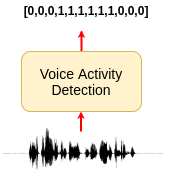

As an alternative, the VAD could provide in the output the **boundaries** where speech activity is detected. For instance:



```
segment_001  0.00  2.57 NON_SPEECH
segment_002  2.57  8.20 SPEECH
segment_003  8.20  9.10 NON_SPEECH
segment_004  9.10  10.93 SPEECH
segment_005  10.93  12.00 NON_SPEECH
segment_006  12.00  14.40 SPEECH
segment_007  14.40  15.00 NON_SPEECH
```


## What is VAD useful for?

A VAD plays a crucial role in many speech processing pipelines. It is used when we would like to apply the processing algorithms to the **speech parts** of the audio recording only.  

For instance, it is often employed as a **pre-processing step** for speech recognition, speech enhancement, speaker diarization, and many others systems.


## Why is challenging?

Discriminating speech from non-speech signals is very natural for humans. However, for a machine, this is much tricker. A good VAD should precisely detect speech activity even in **noisy** and **reverberant** conditions. The number of possible noise sources is huge in **real-life** conditions (e.g., music, telephone rings, alarms, etc.), making the problem challenging for a machine.

Moreover, a good VAD should be able to process both short and very **long recordings** (e.g., meetings) and, ideally, shouldn't be too computationally expensive.








## Pipeline description

Robust Voice Activity Detection has been a very active research field for decades. Today, deep learning plays a crucial role in this problem as well.

In this tutorial, we employ a neural network that provides speech/non-speech predictions for each input frame. The frame-level posterior probabilities are then post-processed to retrieve the final speech boundaries, as shown in the following figure:


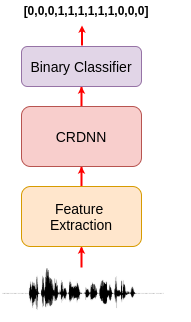

More precisely, we here compute the standard FBANK features and we plug them into a CRDNN model (which combines convolutional, recurrent, and fully connected layers). The output is processed with a **sigmoid** to perform a **binary classification**. The network is trained with **binary cross-entropy**. The predictions will be close to one for speech and close to zero for non-speech frames.

At inference time, the binary predictions are post-processed. For instance, we apply a **threshold** on them to identify the candidate speech regions. After that, we can apply other types of post-processing, such as merging segments that are close or remove segments that are too short. We will describe this in detail in the inference section.

Right now, let's briefly discuss how we can train such a model with SpeechBrain.

## Training
SpeechBrain has a recipe for training a VAD with the [LibriParty Dataset](https://www.dropbox.com/s/ebo987wu3hie3zm/LibriParty.tar.gz?e=1&st=bjjs0754&dl=1). This is a dataset that we created for tasks such a VAD training. It contains several simulated acoustic scenes with speech and noisy sequences periodically active (alone or simultaneously).

Beyond that, the training recipe creates **on-the-fly** several other **simulated acoustic scenes** using the Musan (that contains speech, noise, and music signals), CommonLanguage (that contains speech from 48 languages), and open-rir (that contains noise and impulse responses).

The acoustic scene simulated on the fly explores different scenarios such as noise + speech, speech to noise transitions, noise to speech transitions, etc.

Similarly to the other SpeechBrain recipes, one can train the model with the following commands:



```bash
cd recipes/LibriParty/VAD
python train.py hparams/train.yaml
```

Please, follow the README file available within the recipe and make sure you have downloaded all the data before starting the training.

Apart from the **massive use of speech augmentation/contamination**, the recipe has nothing special. Let's thus focus more on the inference part, which relies on some custom components.




## Inference

We can now focus on the inference part. The inference part is a bit more elaborated than usual because we designed it to work on very **long recordings** and to support several techniques for **post-processing** the network predictions.

We will address all of the aforementioned aspects. But, let's first install speechbrain:

In [ ]:
%%capture
# Installing SpeechBrain via pip
BRANCH = 'develop'
!python -m pip install git+https://github.com/speechbrain/speechbrain.git@$BRANCH

In [ ]:
%%capture
!wget -O /content/example_vad_music.wav "https://www.dropbox.com/scl/fi/vvffxbkkuv79g0d4c7so3/example_vad_music.wav?rlkey=q5m5wc6y9fsfvt43x5yy8ohrf&dl=1"

Let's read a speech signal:

In [ ]:
import torch
import torchaudio
import matplotlib.pyplot as plt

audio_file = "/content/example_vad_music.wav"
signal, fs = torchaudio.load(audio_file)
signal = signal.squeeze()
time = torch.linspace(0, signal.shape[0]/fs, steps=signal.shape[0])

plt.plot(time, signal)

from IPython.display import Audio
Audio(audio_file)

We can now use the VAD trained at the previous step in the following way:


In [ ]:
from speechbrain.inference.VAD import VAD

VAD = VAD.from_hparams(source="speechbrain/vad-crdnn-libriparty", savedir="pretrained_models/vad-crdnn-libriparty")
boundaries = VAD.get_speech_segments(audio_file)
VAD.save_boundaries(boundaries)


As you can see, the two speech parts are detected correctly. The music part is correctly classified as a non-speech segment, while the part where both music and speech are active is classified as speech.

## Inference Pipeline (Details)

The pipeline for detecting the speech segments is the following:

1. Compute **posteriors probabilities** at the frame level.
2. Apply a **threshold** on the posterior probability.
3. Derive candidate speech segments on top of that.
4. Apply **energy VAD** within each candidate segment (optional).
5. **Merge segments** that are too close.
6. **Remove segments** that are too short.
7. **Double-check speech** segments (optional).

To make debugging easier and the interface more **modular** and **transparent**, we allow users to access the output of these intermediate steps.

In some cases, these steps are not all needed. Users are free to customize the pipeline and its hyperparameters to improve the performance on their data.


Let's start with the posterior computation.

### 1- Posterior Computation
The neural model provides outputs that should be close to zero for non-speech frames and close 1 one from speech frames.

The time resolution depends on the **feature extraction** part and on the adopted neural **model**. In this case, we have a prediction every 10 ms (which is pretty standard for speech processing).

To compute the posterior probabilities, you can use the following command:

In [ ]:
prob_chunks = VAD.get_speech_prob_file(audio_file)
plt.plot(prob_chunks.squeeze())

As expected, we have high values for speech regions and low values for the music one.

The `get_speech_prob_file function` is designed to process **long audio recordings**. It computes posterior probabilities on large chunks (e.g., 30 sec), that are read sequentially to avoid storing long signals in memory.
Each large chunk is, in turn, split into smaller ones (e.g., 10 seconds)
that are processed in parallel.

You can tune the `large_chunk_size` and `small_chunk_size` based on your memory constraints. If you have enough memory, you can use it to store a larger chunk of the signal (e.g., 5 minutes). This can be done by increasing `large_chunk_size` and will make the VAD (slightly) faster.



### 2- Apply a Threshold

Now, we can detect the candidate speech segments by applying a threshold.

To do it, you can use the following function:

In [ ]:
prob_th = VAD.apply_threshold(prob_chunks, activation_th=0.5, deactivation_th=0.25).float()
plt.plot(prob_th.squeeze())

Instead of applying a single threshold (e.g., 0.5),  we allow users to set two different thresholds, one to decide when to start a speech segment (`activation_th`) and one to detect when to stop it (`deactivation_th`).

According to our experience, it makes sense to set `activation_th` higher than than `deactivation_th` (e.g, `aactivation_th=0.5`, `deactivation_th=0.25`).

Users, however, can play with these hyperparameters to make the VAD more or less selective.


### 3- Get the Boundaries
Now, we can derive the boundaries of the speech segments from the thresholded posteriors:


In [ ]:
boundaries = VAD.get_boundaries(prob_th)
VAD.save_boundaries(boundaries, audio_file=audio_file)

The `boundaries` tensors contain the beginning and end second of each speech segment.
The method `save_boundaries` can be used to plot the boundaries in a human-readable format and/or to save them on a file (with the `save_path` argument).

### 4- Energy-based VAD (optional)

The trained neural VAD tends to detect large speech segments, where smaller speech segments that are close to each other are merged.

If the users want more resolution, one possible approach is to apply an **energy-based VAD** within the detected speech segments. The energy-based VAD processes the speech segments with sliding windows that compute the energy within each chunk.  The energy profile is normalized such that we have  0.5 and +-0.5 of standard deviation. We then apply a threshold and split the speech original segment into smaller ones.

This is done in the following way:

In [ ]:
boundaries = VAD.energy_VAD(audio_file,boundaries, activation_th=0.8, deactivation_th=0.0)
VAD.save_boundaries(boundaries, audio_file=audio_file)

Users can have a more or less selective VAD by playing with `activation_th` and `deactivation_th`.

Differently from the neural VAD, the energy VAD tends to oversegment the input. We improve that by post-processing the boundaries, as will be shown below.

### 5- Merge close segments
The users might need to select the desired resolution for the VAD (the optimal level of granularity might depend on the task).

For instance, it could make sense to **merge segments** that are too close to each other.

This is done with the following method:

In [ ]:
# 5- Merge segments that are too close
boundaries = VAD.merge_close_segments(boundaries, close_th=0.250)
VAD.save_boundaries(boundaries, audio_file=audio_file)


In this case, we merged segments that are closer than 250 ms. Users can play with `close_th` and tune it according to their needs.

### 6- Remove short segments
It could also make sense to remove short isolated segments that might be misclassified as speech:

In [ ]:
# 6- Remove segments that are too short
boundaries = VAD.remove_short_segments(boundaries, len_th=0.250)
VAD.save_boundaries(boundaries, audio_file=audio_file)

In this case, we remove segments that are shorter than 250 ms. Note that we first merged segments that are close and only after we removed the short ones. This helps to remove short "isolated"  segments only.

### 7- Double check speech segments (optional)

At this point, we can take the post-processed speech segments and double-check if they really contain speech. This is done in this way:

In [ ]:
# 7- Double-check speech segments (optional).
boundaries = VAD.double_check_speech_segments(boundaries, audio_file,  speech_th=0.5)
VAD.save_boundaries(boundaries, audio_file=audio_file)

The method uses one more time the neural VAD on the detected speech segments. If the **average posterior probability within the segment** is larger than `speech_th` (in this case, `speech_th=0.5`), the speech segment is confirmed. Otherwise,  it is removed.



## Visualization

We also implemented some utilities to help users visualizing the output of the VAD:

In [ ]:
upsampled_boundaries = VAD.upsample_boundaries(boundaries, audio_file)

This function creates a "VAD signal" with the **same dimensionality** as the original audio recording. This way, one can plot them jointly:

In [ ]:
time = torch.linspace(0, signal.shape[0]/fs, steps=signal.shape[0])
plt.plot(time, signal)
plt.plot(time, upsampled_boundaries.squeeze())

For more details, one can also upsample and visualize VAD scores:

In [ ]:
upsampled_vad_scores = VAD.upsample_VAD(prob_chunks, audio_file)

plt.plot(time, signal)
plt.plot(time, upsampled_boundaries.squeeze())
plt.plot(time, upsampled_vad_scores.squeeze())

As an alternative, users can save the VAD file and open it with the original one using an audio visualization software like audacity.


**That's all! Happy VAD!**




---

## Appendix: on using energy-based VAD

If energy-based VAD is used, the order of the merge, remove, double-check operations matters. Let's use `double_check_speech_segments` right away after energy-based VAD and then `merge_close_segments`. Some speech frames are dropped:

In [ ]:
# plotted boundaries may be scaled down to compare many at once
def plot_boundaries(b, color):
  upsampled = VAD.upsample_boundaries(b, audio_file)
  plt.plot(time, upsampled.squeeze(), color)


# first figures - from CRDNN VAD to energy VAD
fig, axs = plt.subplots(3, 3, figsize=(16, 12))
plt.sca(axs[0, 0])
plt.title('1a. CRDNN VAD scores')
plt.plot(time, signal)

plt.plot(time, upsampled_vad_scores.squeeze(), 'green')

# CRDNN boundaries
plt.sca(axs[1, 0])
plt.title('1b. CRDNN VAD boundaries')
plt.plot(time, signal)

boundaries = VAD.get_boundaries(prob_th)
plot_boundaries(boundaries, 'orange')

# energy VAD boundaries
plt.sca(axs[2, 0])
plt.title('1c. Energy VAD boundaries based on CRDNN')
plt.plot(time, signal)

boundaries_energy = VAD.energy_VAD(audio_file, boundaries, activation_th=0.8, deactivation_th=0.0)
plot_boundaries(boundaries_energy, 'purple')

# second figure - double-check, then merge
plt.sca(axs[0, 1])
plt.title('2a. Energy VAD (same as 1c)')
plt.plot(time, signal)

plot_boundaries(boundaries_energy, 'purple')

# double-check
plt.sca(axs[1, 1])
plt.title('2b. Double-check (too early)')
plt.plot(time, signal)

boundaries = VAD.double_check_speech_segments(boundaries_energy, audio_file,  speech_th=0.5)
plot_boundaries(boundaries, 'red')

# merge (too late)
plt.sca(axs[2, 1])
plt.title('2c. Merge short segments (too late)')
plt.plot(time, signal)

boundaries = VAD.merge_close_segments(boundaries, close_th=0.250)
plot_boundaries(boundaries, 'black')

# third figure - merge, remove, double-check
plt.sca(axs[0, 2])
plt.title('3a. Energy VAD (same as 1c)')
plt.plot(time, signal)

plot_boundaries(boundaries_energy, 'purple')

# merge
plt.sca(axs[1, 2])
plt.title('3b. Merge short segments (as above)')
plt.plot(time, signal)

boundaries = VAD.merge_close_segments(boundaries_energy, close_th=0.250)
plot_boundaries(boundaries, 'black')

# merge
plt.sca(axs[2, 2])
plt.title('3c. Remove short segments & double-check (as above)')
plt.plot(time, signal)

boundaries = VAD.remove_short_segments(boundaries, len_th=0.250)
boundaries = VAD.double_check_speech_segments(boundaries, audio_file,  speech_th=0.5)
plot_boundaries(boundaries, 'red')

## Citing SpeechBrain

If you use SpeechBrain in your research or business, please cite it using the following BibTeX entry:

```bibtex
@misc{speechbrainV1,
  title={Open-Source Conversational AI with {SpeechBrain} 1.0},
  author={Mirco Ravanelli and Titouan Parcollet and Adel Moumen and Sylvain de Langen and Cem Subakan and Peter Plantinga and Yingzhi Wang and Pooneh Mousavi and Luca Della Libera and Artem Ploujnikov and Francesco Paissan and Davide Borra and Salah Zaiem and Zeyu Zhao and Shucong Zhang and Georgios Karakasidis and Sung-Lin Yeh and Pierre Champion and Aku Rouhe and Rudolf Braun and Florian Mai and Juan Zuluaga-Gomez and Seyed Mahed Mousavi and Andreas Nautsch and Xuechen Liu and Sangeet Sagar and Jarod Duret and Salima Mdhaffar and Gaelle Laperriere and Mickael Rouvier and Renato De Mori and Yannick Esteve},
  year={2024},
  eprint={2407.00463},
  archivePrefix={arXiv},
  primaryClass={cs.LG},
  url={https://arxiv.org/abs/2407.00463},
}
@misc{speechbrain,
  title={{SpeechBrain}: A General-Purpose Speech Toolkit},
  author={Mirco Ravanelli and Titouan Parcollet and Peter Plantinga and Aku Rouhe and Samuele Cornell and Loren Lugosch and Cem Subakan and Nauman Dawalatabad and Abdelwahab Heba and Jianyuan Zhong and Ju-Chieh Chou and Sung-Lin Yeh and Szu-Wei Fu and Chien-Feng Liao and Elena Rastorgueva and François Grondin and William Aris and Hwidong Na and Yan Gao and Renato De Mori and Yoshua Bengio},
  year={2021},
  eprint={2106.04624},
  archivePrefix={arXiv},
  primaryClass={eess.AS},
  note={arXiv:2106.04624}
}
```